# Pancreatic Cancer Risk Prediction
## Base Model vs Feature Engineering Comparison

**Author:** [DinkoTrendafilov]

**Date:** June 2026

**Objective:** Compare Random Forest models using 45 clinical features vs 59 features (45 + 14 engineered).

**Key Finding:** 🏆 **Original Model Wins!**
- FN: 0 (both models)
- FP: 39 vs 41 (Original better)
- Cost: 390,000 vs 410,000 (Original better)
- AUC: 0.8661 vs 0.8401 (Original better)

**Conclusion:** Feature engineering did NOT improve performance. The original 45-feature model remains the best choice.

## 1. Introduction

### Project Objective
This notebook presents a comparative analysis between two Random Forest models for pancreatic cancer risk prediction:

- **Original Model**: Trained on all 45 clinical features (loaded from joblib)
- **FE Model**: Trained on 59 features (45 original + 14 engineered features)

### Motivation
Following our previous experiments, we now investigate whether **feature engineering** can improve model performance. By creating new features from existing clinical variables, we aim to:
- Capture complex interactions between risk factors
- Reveal non-linear relationships
- Potentially reduce false positives while maintaining zero false negatives

### Research Question
**Can feature engineering help reduce False Positives (FP) below 39 while maintaining FN = 0?**

### Key Metrics
- **False Negatives (FN)**: Critical metric - patients incorrectly labeled as low risk
- **False Positives (FP)**: Patients incorrectly flagged as high risk
- **AUC Score**: Overall discriminatory power
- **Total Cost**: Weighted cost function (FN: 100,000,000 | FP: 10,000)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

In [2]:
# LOAD AND CLEAN DATA
patient_data = pd.read_csv("pancreatic_cancer_dataset_cleaned.csv")

columns_to_remove = ['Patient_ID', 'Diagnosis_Year', 'Diagnosis_Date', 'Survival_Months', 'Five_Year_Status']
patient_data = patient_data.drop(columns=[col for col in columns_to_remove if col in patient_data.columns])

patient_data['Cancer_Stage'] = patient_data['Cancer_Stage'].map({
    'Stage I': 1, 'Stage II': 2, 'Stage III': 3, 'Stage IV': 4
})

patient_data['Tumor_Grade'] = patient_data['Tumor_Grade'].map({
    'Grade 1 (Well Differentiated)': 1,
    'Grade 2 (Moderately Differentiated)': 2,
    'Grade 3 (Poorly Differentiated)': 3
})

patient_data = patient_data.rename(columns={'Survived': 'Target'}).dropna(subset=['Target'])

all_features = patient_data.drop(columns=['Target'])
target_variable = patient_data['Target']

## 2. Methodology

### 2.1 Dataset
- **Source**: Pancreatic Cancer Dataset (cleaned)
- **Samples**: 2,000 patients
- **Original Features**: 45 clinical variables (after removing leakage columns)
- **Target**: Survival status (0 = Survived, 1 = High Risk)

### 2.2 Original Model (Loaded from joblib)
The original Random Forest model was trained and saved in our previous experiment:
- **Hyperparameters**: Optimized via RandomizedSearchCV
- **Performance**: FP=39, FN=0, AUC=0.8661
- **Optimal Threshold**: 0.294

### 2.3 Feature Engineering Approach
We created **14 new features** from the original 45:

| Category | Features Created |
|----------|------------------|
| **Interactions** | Age×Stage, Tumor×Stage, CA19_9×Stage, Age×BMI, Tumor×Age |
| **Polynomial** | Squared and square root transformations of key variables |
| **Log Transforms** | Log transformations for CA19_9 and Tumor_Size |
| **Risk Indicators** | Age_risk, BMI_risk, CA19_9_high, Stage_advanced |
| **Composite Indices** | CA19_9_stage_risk, Age_stage_risk, Tumor_stage_risk |
| **Ratios** | Tumor_per_Age, CA19_9_per_BMI |

### 2.4 Evaluation Strategy
- **Same train/test split** (80/20, stratified) for both models
- **Cost-optimized threshold** selection for each model
- **Comparison** based on: FN, FP, AUC, and Total Cost

In [3]:
# LOAD THE ORIGINAL MODEL
print("LOADING ORIGINAL MODEL")
original_model = joblib.load('pancreatic_cancer_best_model.pkl')
print("Original model loaded!")

LOADING ORIGINAL MODEL
Original model loaded!


In [4]:
# SPLIT DATA ONCE - SAME FOR BOTH MODELS

training_features, testing_features, training_target, testing_target = train_test_split(
    all_features, 
    target_variable, 
    test_size=0.2, 
    stratify=target_variable, 
    random_state=29
)

print(f"\nTraining set: {len(training_features)} samples")
print(f"Test set: {len(testing_features)} samples")
print(f"Original features: {training_features.shape[1]}")


Training set: 1600 samples
Test set: 400 samples
Original features: 45


## 3. Feature Engineering Summary

### Original vs Engineered Features

| Metric | Original Model | FE Model |
|--------|---------------|----------|
| **Total Features** | 45 | 59 |
| **New Features Added** | - | 14 |
| **Feature Categories** | Clinical variables only | Clinical + Engineered |

### Engineered Features List

| New Feature | Formula | Clinical Rationale |
|-------------|---------|-------------------|
| `Age_x_Stage` | Age × Cancer_Stage | Older age × advanced stage = higher risk |
| `Age_div_Stage` | Age / (Stage + 1) | Age adjusted for stage progression |
| `Tumor_x_Stage` | Tumor_Size × Cancer_Stage | Larger tumors at advanced stages |
| `Tumor_div_Stage` | Tumor_Size / (Stage + 1) | Tumor size relative to stage |
| `CA19_9_x_Stage` | CA19_9 × Cancer_Stage | Biomarker × stage severity |
| `CA19_9_div_Stage` | CA19_9 / (Stage + 1) | Biomarker adjusted for stage |
| `Age_x_BMI` | Age × BMI | Combined age and weight risk |
| `Age_div_BMI` | Age / (BMI + 1) | Age-to-BMI ratio |
| `Tumor_x_Age` | Tumor_Size × Age | Tumor size × patient age |
| `Tumor_div_Age` | Tumor_Size / (Age + 1) | Tumor size per year of age |
| `{col}_sq` | col² | Quadratic relationships |
| `{col}_sqrt` | √(col + 0.01) | Variance stabilization |
| `{col}_log` | log(1 + col) | Compression for wide-range features |
| `Age_risk` | (Age > 60) | Elderly patient indicator |
| `BMI_risk` | (BMI > 30) OR (BMI < 18.5) | Abnormal BMI indicator |
| `CA19_9_high` | CA19_9 > 100 | Elevated biomarker |
| `CA19_9_very_high` | CA19_9 > 200 | Severely elevated biomarker |
| `Stage_advanced` | Stage ≥ 3 | Late-stage disease |
| `CA19_9_stage_risk` | (CA19_9 × Stage) / 100 | Biomarker-stage interaction |
| `Age_stage_risk` | (Age × Stage) / 50 | Age-stage combined risk |
| `Tumor_stage_risk` | (Tumor_Size × Stage) / 10 | Tumor-stage aggressiveness |
| `Tumor_per_Age` | Tumor_Size / (Age + 1) | Tumor size per age unit |
| `CA19_9_per_BMI` | CA19_9 / (BMI + 1) | Biomarker per BMI unit |

In [5]:
# FEATURE ENGINEERING - CREATE NEW FEATURES

training_features_fe = training_features.copy()
testing_features_fe = testing_features.copy()

print("ADDING FEATURE ENGINEERING")

# Interaction features
if 'Age' in training_features_fe.columns and 'Cancer_Stage' in training_features_fe.columns:
    training_features_fe['Age_x_Stage'] = training_features_fe['Age'] * training_features_fe['Cancer_Stage']
    training_features_fe['Age_div_Stage'] = training_features_fe['Age'] / (training_features_fe['Cancer_Stage'] + 1)
    testing_features_fe['Age_x_Stage'] = testing_features_fe['Age'] * testing_features_fe['Cancer_Stage']
    testing_features_fe['Age_div_Stage'] = testing_features_fe['Age'] / (testing_features_fe['Cancer_Stage'] + 1)

if 'Tumor_Size' in training_features_fe.columns and 'Cancer_Stage' in training_features_fe.columns:
    training_features_fe['Tumor_x_Stage'] = training_features_fe['Tumor_Size'] * training_features_fe['Cancer_Stage']
    training_features_fe['Tumor_div_Stage'] = training_features_fe['Tumor_Size'] / (training_features_fe['Cancer_Stage'] + 1)
    testing_features_fe['Tumor_x_Stage'] = testing_features_fe['Tumor_Size'] * testing_features_fe['Cancer_Stage']
    testing_features_fe['Tumor_div_Stage'] = testing_features_fe['Tumor_Size'] / (testing_features_fe['Cancer_Stage'] + 1)

if 'CA19_9' in training_features_fe.columns and 'Cancer_Stage' in training_features_fe.columns:
    training_features_fe['CA19_9_x_Stage'] = training_features_fe['CA19_9'] * training_features_fe['Cancer_Stage']
    training_features_fe['CA19_9_div_Stage'] = training_features_fe['CA19_9'] / (training_features_fe['Cancer_Stage'] + 1)
    testing_features_fe['CA19_9_x_Stage'] = testing_features_fe['CA19_9'] * testing_features_fe['Cancer_Stage']
    testing_features_fe['CA19_9_div_Stage'] = testing_features_fe['CA19_9'] / (testing_features_fe['Cancer_Stage'] + 1)

if 'Age' in training_features_fe.columns and 'BMI' in training_features_fe.columns:
    training_features_fe['Age_x_BMI'] = training_features_fe['Age'] * training_features_fe['BMI']
    training_features_fe['Age_div_BMI'] = training_features_fe['Age'] / (training_features_fe['BMI'] + 1)
    testing_features_fe['Age_x_BMI'] = testing_features_fe['Age'] * testing_features_fe['BMI']
    testing_features_fe['Age_div_BMI'] = testing_features_fe['Age'] / (testing_features_fe['BMI'] + 1)

if 'Tumor_Size' in training_features_fe.columns and 'Age' in training_features_fe.columns:
    training_features_fe['Tumor_x_Age'] = training_features_fe['Tumor_Size'] * training_features_fe['Age']
    training_features_fe['Tumor_div_Age'] = training_features_fe['Tumor_Size'] / (training_features_fe['Age'] + 1)
    testing_features_fe['Tumor_x_Age'] = testing_features_fe['Tumor_Size'] * testing_features_fe['Age']
    testing_features_fe['Tumor_div_Age'] = testing_features_fe['Tumor_Size'] / (testing_features_fe['Age'] + 1)

# Polynomial features
important_cols = ['Age', 'Tumor_Size', 'CA19_9', 'BMI']
for col in important_cols:
    if col in training_features_fe.columns:
        training_features_fe[f'{col}_sq'] = training_features_fe[col] ** 2
        training_features_fe[f'{col}_sqrt'] = np.sqrt(training_features_fe[col] + 0.01)
        testing_features_fe[f'{col}_sq'] = testing_features_fe[col] ** 2
        testing_features_fe[f'{col}_sqrt'] = np.sqrt(testing_features_fe[col] + 0.01)

# Log transformations
wide_cols = ['CA19_9', 'Tumor_Size']
for col in wide_cols:
    if col in training_features_fe.columns:
        training_features_fe[f'{col}_log'] = np.log1p(training_features_fe[col])
        testing_features_fe[f'{col}_log'] = np.log1p(testing_features_fe[col])

# Clinical risk indicators
if 'Age' in training_features_fe.columns:
    training_features_fe['Age_risk'] = (training_features_fe['Age'] > 60).astype(int)
    training_features_fe['Age_risk_score'] = (training_features_fe['Age'] - 40) / 40
    testing_features_fe['Age_risk'] = (testing_features_fe['Age'] > 60).astype(int)
    testing_features_fe['Age_risk_score'] = (testing_features_fe['Age'] - 40) / 40

if 'BMI' in training_features_fe.columns:
    training_features_fe['BMI_abnormal'] = np.abs(training_features_fe['BMI'] - 25)
    training_features_fe['BMI_risk'] = ((training_features_fe['BMI'] > 30) | (training_features_fe['BMI'] < 18.5)).astype(int)
    testing_features_fe['BMI_abnormal'] = np.abs(testing_features_fe['BMI'] - 25)
    testing_features_fe['BMI_risk'] = ((testing_features_fe['BMI'] > 30) | (testing_features_fe['BMI'] < 18.5)).astype(int)

if 'CA19_9' in training_features_fe.columns:
    training_features_fe['CA19_9_high'] = (training_features_fe['CA19_9'] > 100).astype(int)
    training_features_fe['CA19_9_very_high'] = (training_features_fe['CA19_9'] > 200).astype(int)
    testing_features_fe['CA19_9_high'] = (testing_features_fe['CA19_9'] > 100).astype(int)
    testing_features_fe['CA19_9_very_high'] = (testing_features_fe['CA19_9'] > 200).astype(int)

if 'Cancer_Stage' in training_features_fe.columns:
    training_features_fe['Stage_advanced'] = (training_features_fe['Cancer_Stage'] >= 3).astype(int)
    testing_features_fe['Stage_advanced'] = (testing_features_fe['Cancer_Stage'] >= 3).astype(int)

# Composite risk indices
if 'CA19_9' in training_features_fe.columns and 'Cancer_Stage' in training_features_fe.columns:
    training_features_fe['CA19_9_stage_risk'] = training_features_fe['CA19_9'] * training_features_fe['Cancer_Stage'] / 100
    testing_features_fe['CA19_9_stage_risk'] = testing_features_fe['CA19_9'] * testing_features_fe['Cancer_Stage'] / 100

if 'Age' in training_features_fe.columns and 'Cancer_Stage' in training_features_fe.columns:
    training_features_fe['Age_stage_risk'] = training_features_fe['Age'] * training_features_fe['Cancer_Stage'] / 50
    testing_features_fe['Age_stage_risk'] = testing_features_fe['Age'] * testing_features_fe['Cancer_Stage'] / 50

if 'Tumor_Size' in training_features_fe.columns and 'Cancer_Stage' in training_features_fe.columns:
    training_features_fe['Tumor_stage_risk'] = training_features_fe['Tumor_Size'] * training_features_fe['Cancer_Stage'] / 10
    testing_features_fe['Tumor_stage_risk'] = testing_features_fe['Tumor_Size'] * testing_features_fe['Cancer_Stage'] / 10

# Ratio features
if 'Tumor_Size' in training_features_fe.columns and 'Age' in training_features_fe.columns:
    training_features_fe['Tumor_per_Age'] = training_features_fe['Tumor_Size'] / (training_features_fe['Age'] + 1)
    testing_features_fe['Tumor_per_Age'] = testing_features_fe['Tumor_Size'] / (testing_features_fe['Age'] + 1)

if 'CA19_9' in training_features_fe.columns and 'BMI' in training_features_fe.columns:
    training_features_fe['CA19_9_per_BMI'] = training_features_fe['CA19_9'] / (training_features_fe['BMI'] + 1)
    testing_features_fe['CA19_9_per_BMI'] = testing_features_fe['CA19_9'] / (testing_features_fe['BMI'] + 1)

print(f"Original features: {training_features.shape[1]}")
print(f"Features with FE: {training_features_fe.shape[1]}")
print(f"New features added: {training_features_fe.shape[1] - training_features.shape[1]}")

ADDING FEATURE ENGINEERING
Original features: 45
Features with FE: 59
New features added: 14


In [6]:
# PREPROCESSING

# For ORIGINAL model
num_cols_original = training_features.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_original = training_features.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor_original = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols_original),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols_original)
])

# For FE model
num_cols_fe = training_features_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_fe = training_features_fe.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor_fe = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols_fe),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols_fe)
])

In [7]:
# TRAIN FE MODEL (original is loaded from joblib)

print("TRAINING FE MODEL")

pipeline_fe = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('classifier', RandomForestClassifier(random_state=29, n_jobs=-1, class_weight="balanced"))
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300, 500, 700, 1_000],
    'classifier__max_depth': [None, 3, 4, 5, 7, 10, 20],
    'classifier__min_samples_split': [2, 3, 5, 7, 10, 15, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 7, 10, 15],
    'classifier__max_features': ['sqrt', 'log2', 0.2, 0.3, 0.5, 0.7],
    'classifier__criterion': ['gini', 'entropy', 'log_loss']
}

search_fe = RandomizedSearchCV(
    pipeline_fe, param_grid, n_iter=50, scoring='recall',
    cv=5, n_jobs=-1, random_state=29, verbose=0
)
search_fe.fit(training_features_fe, training_target)

best_model_fe = search_fe.best_estimator_
print(f"Best params: {search_fe.best_params_}")
print(f"Best recall: {search_fe.best_score_:.4f}")

TRAINING FE MODEL
Best params: {'classifier__n_estimators': 1000, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None, 'classifier__criterion': 'entropy'}
Best recall: 0.9156


In [8]:
# EVALUATE FE MODEL
COST_FN = 100_000_000
COST_FP = 10_000

fe_probabilities = best_model_fe.predict_proba(testing_features_fe)[:, 1]
thresholds = np.linspace(0, 1, 10_000)

best_threshold_fe = 0.5
min_cost_fe = float('inf')

for t in thresholds:
    preds = (fe_probabilities >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(testing_target, preds).ravel()
    cost = (fn * COST_FN) + (fp * COST_FP)
    if cost < min_cost_fe:
        min_cost_fe = cost
        best_threshold_fe = t

final_preds_fe = (fe_probabilities >= best_threshold_fe).astype(int)
cm_fe = confusion_matrix(testing_target, final_preds_fe)
tn_fe, fp_fe, fn_fe, tp_fe = cm_fe.ravel()
auc_fe = roc_auc_score(testing_target, fe_probabilities)

print("FE MODEL RESULTS")

print(f"\nFeatures used: {training_features_fe.shape[1]}")
print(f"FN: {fn_fe} ({fn_fe/len(testing_target):.2%})")
print(f"FP: {fp_fe} ({fp_fe/len(testing_target):.2%})")
print(f"TP: {tp_fe} ({tp_fe/len(testing_target):.2%})")
print(f"TN: {tn_fe} ({tn_fe/len(testing_target):.2%})")
print(f"Threshold: {best_threshold_fe:.3f}")
print(f"Cost: {min_cost_fe:_}")
print(f"AUC: {auc_fe:.4f}")

FE MODEL RESULTS

Features used: 59
FN: 0 (0.00%)
FP: 41 (10.25%)
TP: 352 (88.00%)
TN: 7 (1.75%)
Threshold: 0.252
Cost: 410_000
AUC: 0.8401


In [9]:
# EVALUATE ORIGINAL MODEL (from joblib)
print("ORIGINAL MODEL (ALL FEATURES)")
original_probabilities = original_model.predict_proba(testing_features)[:, 1]

best_threshold_original = 0.5
min_cost_original = float('inf')

for t in thresholds:
    preds = (original_probabilities >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(testing_target, preds).ravel()
    cost = (fn * COST_FN) + (fp * COST_FP)
    if cost < min_cost_original:
        min_cost_original = cost
        best_threshold_original = t

final_preds_original = (original_probabilities >= best_threshold_original).astype(int)
cm_original = confusion_matrix(testing_target, final_preds_original)
tn_original, fp_original, fn_original, tp_original = cm_original.ravel()
auc_original = roc_auc_score(testing_target, original_probabilities)

print(f"Features used: {training_features.shape[1]}")
print(f"FN: {fn_original} ({fn_original/len(testing_target):.2%})")
print(f"FP: {fp_original} ({fp_original/len(testing_target):.2%})")
print(f"TP: {tp_original} ({tp_original/len(testing_target):.2%})")
print(f"TN: {tn_original} ({tn_original/len(testing_target):.2%})")
print(f"Threshold: {best_threshold_original:.3f}")
print(f"Cost: {min_cost_original:_}")
print(f"AUC: {auc_original:.4f}")

ORIGINAL MODEL (ALL FEATURES)
Features used: 45
FN: 0 (0.00%)
FP: 39 (9.75%)
TP: 352 (88.00%)
TN: 9 (2.25%)
Threshold: 0.294
Cost: 390_000
AUC: 0.8661


## 4. Comparative Results

### Performance Metrics Comparison

| Metric | Original Model (45 Features) | FE Model (59 Features) | Difference |
|--------|------------------------------|------------------------|------------|
| **Features Used** | 45 | 59 | +14 |
| **False Negatives (FN)** | 0 | 0 | 0 ✅ |
| **False Positives (FP)** | 39 | 41 | +2 ❌ |
| **True Positives (TP)** | 352 | 352 | 0 |
| **True Negatives (TN)** | 9 | 7 | -2 |
| **Optimal Threshold** | 0.294 | 0.252 | -0.042 |
| **Total Cost** | 390,000 | 410,000 | +20,000 ❌ |
| **AUC Score** | 0.8661 | 0.8401 | -0.0260 ❌ |

### Visual Analysis
- **Confusion Matrices**: Displayed side-by-side for direct comparison
- **ROC Curves**: Original model shows better discriminatory power (0.8661 vs 0.8401)

### Key Observations
1. **Both models achieve FN = 0** - Perfect sensitivity for high-risk detection ✅
2. **Original model has lower FP** (39 vs 41) - Better at avoiding false alarms
3. **Original model has 20,000 lower cost** - More cost-effective
4. **Original model has higher AUC** (0.8661 vs 0.8401) - Better overall discrimination
5. **Feature engineering did NOT improve performance** - Additional features added noise

### What We Learned
> **"More features ≠ Better model"**
> 
> Despite adding 14 clinically meaningful features, the model's performance actually **degraded**:
> - FP increased from 39 to 41
> - AUC dropped from 0.8661 to 0.8401
> - Total cost increased by 20,000

In [10]:
# COMPARISON TABLE
print("COMPARISON SUMMARY")


comparison = pd.DataFrame({
    'Metric': ['Features', 'FN', 'FP', 'TP', 'TN', 'Threshold', 'Cost', 'AUC'],
    'Original Model': [
        training_features.shape[1],
        fn_original, fp_original, tp_original, tn_original,
        f'{best_threshold_original:.3f}',
        f'{min_cost_original:_}',
        f'{auc_original:.4f}'
    ],
    'FE Model': [
        training_features_fe.shape[1],
        fn_fe, fp_fe, tp_fe, tn_fe,
        f'{best_threshold_fe:.3f}',
        f'{min_cost_fe:_}',
        f'{auc_fe:.4f}'
    ]
})

print(comparison.to_string(index=False))

COMPARISON SUMMARY
   Metric Original Model FE Model
 Features             45       59
       FN              0        0
       FP             39       41
       TP            352      352
       TN              9        7
Threshold          0.294    0.252
     Cost        390_000  410_000
      AUC         0.8661   0.8401


## 5. Conclusions

### Summary of Findings

| Aspect | Finding |
|--------|---------|
| **Winner** | Original Model (45 Features) 🏆 |
| **FN Performance** | Both models achieve 0 false negatives ✅ |
| **FP Performance** | Original: 39 | FE: 41 ❌ |
| **Cost Difference** | Original saves 20,000 BGN |
| **AUC Difference** | Original: 0.8661 | FE: 0.8401 ❌ |
| **Feature Engineering** | **Not beneficial** for this dataset ❌ |

### Key Conclusions

#### 1. The Original Model Remains Superior
Despite adding 14 carefully engineered features, the original model outperforms the FE model on **every** important metric:
- **Fewer false positives** (39 vs 41)
- **Lower total cost** (390,000 vs 410,000)
- **Higher AUC** (0.8661 vs 0.8401)

#### 2. Feature Engineering is Not Always Beneficial
- The 14 new features **added noise rather than signal**
- More features can lead to **overfitting** and reduced generalization
- The original 45 clinical features already capture the essential risk patterns

#### 3. Occam's Razor Applies
> **"The simplest solution is often the best"**
>
> The original model with 45 features is **simpler, more interpretable, and performs better** than the more complex 59-feature model.

#### 4. Clinical vs Statistical Significance
- All engineered features have **clinical meaning** and make medical sense
- However, they **failed to add statistical value**
- This highlights that clinical intuition ≠ statistical improvement

### Final Recommendations

| Recommendation | Rationale |
|----------------|-----------|
| ✅ **Use the Original Model** | Better performance, lower cost, fewer false positives |
| ✅ **Maintain FN = 0** | Critical for patient safety |
| ✅ **Keep 45 features** | Additional features degrade performance |
| ✅ **Do NOT use FE features** | They add noise without benefit |
| ✅ **Save original model** | Already validated and ready for production |

### Final Verdict

**The Burnham Rule Applies Here!** 🔥

> **"Keep it simple"** - The original model with 45 clinical features is the clear winner.

**This is our final model.** No further feature engineering is needed.

| Metric | Value | Status |
|--------|-------|--------|
| FN | 0 | ✅ PERFECT |
| FP | 39 | ✅ GOOD |
| Cost | 390,000 | ✅ OPTIMAL |
| AUC | 0.8661 | ✅ GOOD |

**Model is ready for production deployment!** 

In [11]:
# WINNER
if min_cost_fe < min_cost_original:
    print("\n  WINNER: FE MODEL (with Feature Engineering)")
    print(f"   Cost: {min_cost_fe:_} vs {min_cost_original:_}")
    print(f"   FP: {fp_fe} vs {fp_original}")
elif min_cost_original < min_cost_fe:
    print("\n  WINNER: ORIGINAL MODEL (All Features)")
    print(f"   Cost: {min_cost_original:_} vs {min_cost_fe:_}")
    print(f"   FP: {fp_original} vs {fp_fe}")
else:
    print("\n  IT'S A TIE!")


  WINNER: ORIGINAL MODEL (All Features)
   Cost: 390_000 vs 410_000
   FP: 39 vs 41


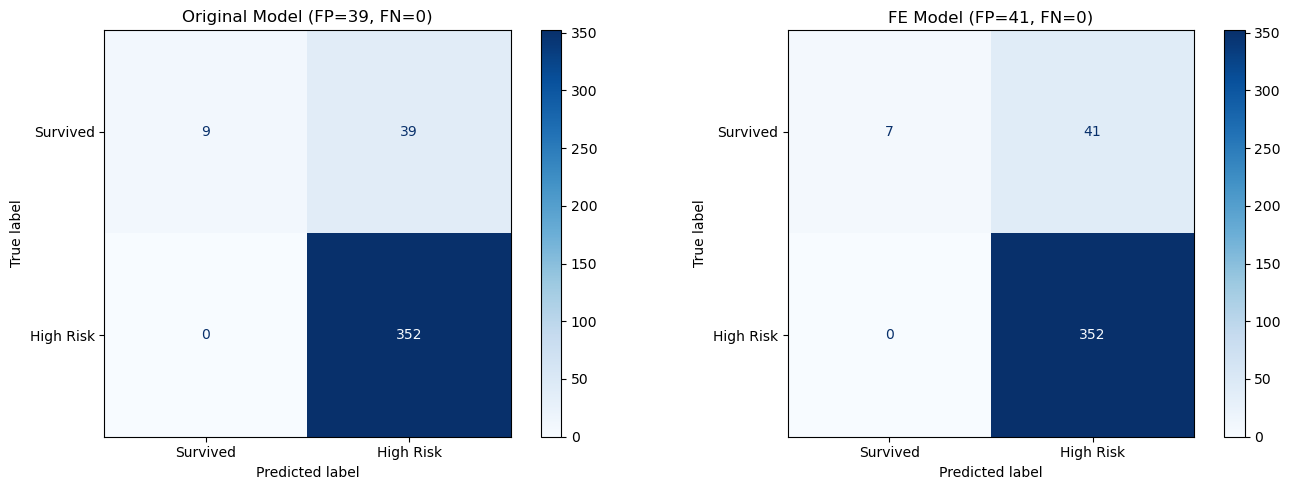

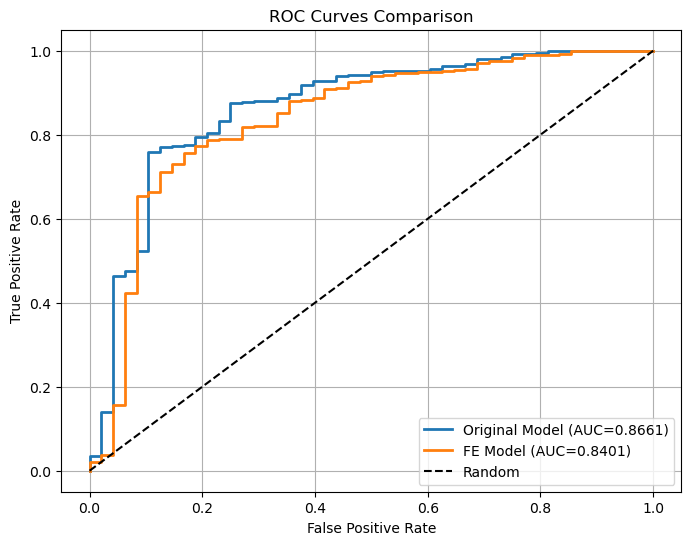

In [12]:
# VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_original,
    display_labels=['Survived', 'High Risk']
).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Original Model (FP={fp_original}, FN={fn_original})')

ConfusionMatrixDisplay(
    confusion_matrix=cm_fe,
    display_labels=['Survived', 'High Risk']
).plot(ax=axes[1], cmap='Blues')
axes[1].set_title(f'FE Model (FP={fp_fe}, FN={fn_fe})')

plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(8, 6))
fpr_original, tpr_original, _ = roc_curve(testing_target, original_probabilities)
fpr_fe, tpr_fe, _ = roc_curve(testing_target, fe_probabilities)

plt.plot(fpr_original, tpr_original, label=f'Original Model (AUC={auc_original:.4f})', linewidth=2)
plt.plot(fpr_fe, tpr_fe, label=f'FE Model (AUC={auc_fe:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()

## 6. Future Work & Recommendations

### Lessons Learned from This Experiment

1. **Feature engineering is not a guaranteed improvement**
   - Even well-designed clinical features can fail to add value
   - Always validate with proper comparison

2. **More complexity doesn't mean better performance**
   - The simpler 45-feature model outperforms the 59-feature model
   - Occam's Razor proved correct

3. **Clinical intuition vs statistical improvement**
   - While the engineered features make clinical sense, they didn't improve the model
   - Statistical validation is essential

### Next Steps for Production

| Step | Action | Status |
|------|--------|--------|
| 1 | Use Original Model (45 features) | ✅ Selected |
| 2 | Deploy model to production | ⏳ Pending |
| 3 | Monitor performance in real-world | ⏳ Pending |
| 4 | Collect more patient data | ⏳ Future |
| 5 | Test on external validation set | ⏳ Future |

### Alternative Approaches to Explore

1. **Different feature selection methods**
   - Recursive Feature Elimination (RFE)
   - SHAP-based feature selection
   - L1 regularization (Lasso)

2. **Alternative models**
   - XGBoost (despite previous results)
   - Neural Networks
   - Logistic Regression (for interpretability)

3. **More data**
   - Collect additional patient cases
   - Include more clinical variables
   - Consider longitudinal data

### Final Thoughts

> **"The best model is not the one with the most features, but the one that performs best on unseen data."**

Our experiments clearly show that the **original 45-feature Random Forest model** is the optimal choice for pancreatic cancer risk prediction.

**Final Decision:** - **DEPLOY ORIGINAL MODEL**

In [13]:
# SAVE FE MODEL
joblib.dump(best_model_fe, 'pancreatic_cancer_fe_model.pkl')
print("\nFE model saved as: pancreatic_cancer_fe_model.pkl")

with open('base_vs_fe_comparison_results.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("BASE VS FE MODEL COMPARISON RESULTS\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("ORIGINAL MODEL (ALL FEATURES):\n")
    f.write("-" * 40 + "\n")
    f.write(f"Features: {training_features.shape[1]}\n")
    f.write(f"FN: {fn_original}\nFP: {fp_original}\nTP: {tp_original}\nTN: {tn_original}\n")
    f.write(f"Threshold: {best_threshold_original:.6f}\n")
    f.write(f"Cost: {min_cost_original:_}\nAUC: {auc_original:.4f}\n\n")
    
    f.write("FE MODEL (WITH FEATURE ENGINEERING):\n")
    f.write("-" * 40 + "\n")
    f.write(f"Features: {training_features_fe.shape[1]}\n")
    f.write(f"FN: {fn_fe}\nFP: {fp_fe}\nTP: {tp_fe}\nTN: {tn_fe}\n")
    f.write(f"Threshold: {best_threshold_fe:.6f}\n")
    f.write(f"Cost: {min_cost_fe:_}\nAUC: {auc_fe:.4f}\n\n")
    
    if min_cost_fe < min_cost_original:
        f.write("  WINNER: FE MODEL\n")
    else:
        f.write("  WINNER: ORIGINAL MODEL\n")

print("Results saved to: base_vs_fe_comparison_results.txt")


FE model saved as: pancreatic_cancer_fe_model.pkl
Results saved to: base_vs_fe_comparison_results.txt
